In [1]:
from typing import Dict, List, Any
from numpy.typing import NDArray

from model_ranking import (
    get_summary_results, 
    per_source_model_results,
    cmb_consistency_score_weighted_average,
    to_target_transfer_correlations_with_norm,
    correlation_table,
    per_target_consis_result_type,
    per_target_performance_result_type,
)
from model_ranking import plot_alpha_sweep_specific_norm

INFO: P [MainThread] 2025-10-29 17:35:13,553 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
consis_keys={
    "EPFL": "EI_consis",
    "Hmito": "EI_consis",
    "Rmito": "EI_consis",
    "VNC": "EI_consis",
}
consis_keys_bckg = {
    "EPFL": "EI_consis_bckg",
    "Hmito": "EI_consis_bckg",
    "Rmito": "EI_consis_bckg",
    "VNC": "EI_consis_bckg",
}
result_folders={
    "EPFL": "finetuned",
    "Hmito": "finetuned",
    "Rmito": "finetuned",
    "VNC": "finetuned",
}

per_target_norms: Dict[str, List[str]] = {
    "EPFL": ["Normalize"],
    "Hmito": ["Normalize"],
    "Rmito": ["Normalize"],
    "VNC": ["Normalize"],
}

perf_key = "F1_eval"
approach="feature_perturbation_consistency"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

In [3]:
NA_UNet_source_models_ETarget = {
    "Hmito": "HtoE_def_Hm_model_NA2",
    "Rmito": "RtoE_def_Rm_model_NA2",
    "VNC": "VtoE_def_V_model_NA2_2",
}
Res_source_models_ETarget = {
    "Hmito": "HtoE_def_Hm_model_Res1",
    "Rmito": "RtoE_def_Rm_model_Res1",
    "VNC": "VtoE_def_V_model_Res1",
}
Unetr_source_models_ETarget = {
    "Hmito": "HtoE_def_Hm_model_Unetr2",
    "Rmito": "RtoE_def_Rm_model_Unetr2",
}
Unet_source_models_ETarget = {
    "Hmito": "HtoE_def_Hm_model4_2",
    "Rmito": "RtoE_def_Rm_model4",
    "VNC": "VtoE_def_V_model2",
}
E_Target_models = [
    NA_UNet_source_models_ETarget, 
    Res_source_models_ETarget, 
    Unet_source_models_ETarget, 
    Unetr_source_models_ETarget
]

In [4]:
NA_UNet_source_models_HTarget = {
    "EPFL": "EtoH_def_E_model_NA2",
    "Rmito": "RtoH_def_Rm_model_NA2",
    "VNC": "VtoH_def_V_model_NA2",
}
Res_source_models_HTarget = {
    "EPFL": "EtoH_def_E_model_Res1",
    "Rmito": "RtoH_def_Rm_model_Res1",
    "VNC": "VtoH_def_V_model_Res1",
}
Unetr_source_models_HTarget = {
    "EPFL": "EtoH_def_E_model_Unetr2",
    "Rmito": "RtoH_def_Rm_model_Unetr2",
}
Unet_source_models_HTarget = {
    "EPFL": "EtoH_def_E_model5",
    "Rmito": "RtoH_def_Rm_model4",
    "VNC": "VtoH_def_V_model2",
}
H_Target_models = [
    NA_UNet_source_models_HTarget, 
    Res_source_models_HTarget, 
    Unet_source_models_HTarget, 
    Unetr_source_models_HTarget
]

In [5]:
NA_UNet_source_models_RTarget = {
    "EPFL": "EtoR_def_E_model_NA2",
    "Hmito": "HtoR_def_Hm_model_NA2",
    "VNC": "VtoR_def_V_model_NA2",
}
Res_source_models_RTarget = {
    "EPFL": "EtoR_def_E_model_Res1",
    "Hmito": "HtoR_def_Hm_model_Res1",
    "VNC": "VtoR_def_V_model_Res1",
}
Unetr_source_models_RTarget = {
    "EPFL": "EtoR_def_E_model_Unetr2",
    "Hmito": "HtoR_def_Hm_model_Unetr2",
}
Unet_source_models_RTarget = {
    "EPFL": "EtoR_def_E_model5",
    "Hmito": "HtoR_def_Hm_model4",
    "VNC": "VtoR_def_V_model2",
}
R_Target_models = [
    NA_UNet_source_models_RTarget, 
    Res_source_models_RTarget, 
    Unet_source_models_RTarget, 
    Unetr_source_models_RTarget
]

In [6]:
NA_UNet_source_models_VTarget = {
    "EPFL": "EtoV_def_E_model_NA2",
    "Hmito": "HtoV_def_Hm_model_NA2",
    "Rmito": "RtoV_def_Rm_model_NA2",
}
Res_source_models_VTarget = {
    "EPFL": "EtoV_def_E_model_Res1",
    "Hmito": "HtoV_def_Hm_model_Res1",
    "Rmito": "RtoV_def_Rm_model_Res1",
}
Unetr_source_models_VTarget = {
    "EPFL": "EtoV_def_E_model_Unetr2",
    "Hmito": "HtoV_def_Hm_model_Unetr2",
    "Rmito": "RtoV_def_Rm_model_Unetr2"
}
Unet_source_models_VTarget = {
    "EPFL": "EtoV_def_E_model5",
    "Hmito": "HtoV_def_Hm_model4",
    "Rmito": "RtoV_def_Rm_model4",
}
V_Target_models = [
    NA_UNet_source_models_VTarget, 
    Res_source_models_VTarget, 
    Unet_source_models_VTarget, 
    Unetr_source_models_VTarget
]

In [7]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "DO": ["a0001", "a0005", "a001", "a002", "a003", "a004", "a005", "a01", "a015", "a02", "a025", "a03"],
}
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["EPFL"]
target_models = {
    "EPFL": E_Target_models,
    "Hmito": H_Target_models,
    "Rmito": R_Target_models,
    "VNC": V_Target_models,
}

In [8]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
        #sources = ["Hmito", "Rmito"]
    elif target == "Hmito":
        sources = ["EPFL", "Rmito", "VNC"]
    elif target == "Rmito":
        sources = ["EPFL", "Hmito", "VNC"]
    else:
        sources = ["Hmito", "Rmito", "VNC"]
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    source_model_types = target_models[target]

    for model_type in source_model_types:
        if target == "EPFL":
            if "Unetr" in model_type["Hmito"]:
                sources = ["Hmito", "Rmito"]
        elif target == "VNC":
            if "Unetr" in model_type["Hmito"]:
                sources = ["EPFL", "Hmito", "Rmito"]
                #sources = ["Hmito", "Rmito"]
        elif target == "Hmito":
            if "Unetr" in model_type["EPFL"]:
                sources = ["EPFL", "Rmito"]
        elif target == "Rmito":
            if "Unetr" in model_type["EPFL"]:
                sources = ["EPFL", "Hmito"]
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: Hmito


100%|██████████| 1/1 [00:00<00:00,  2.87it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00,  3.48it/s]


Source: VNC


...

100%|██████████| 1/1 [00:00<00:00,  4.47it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00,  5.42it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00,  4.92it/s]


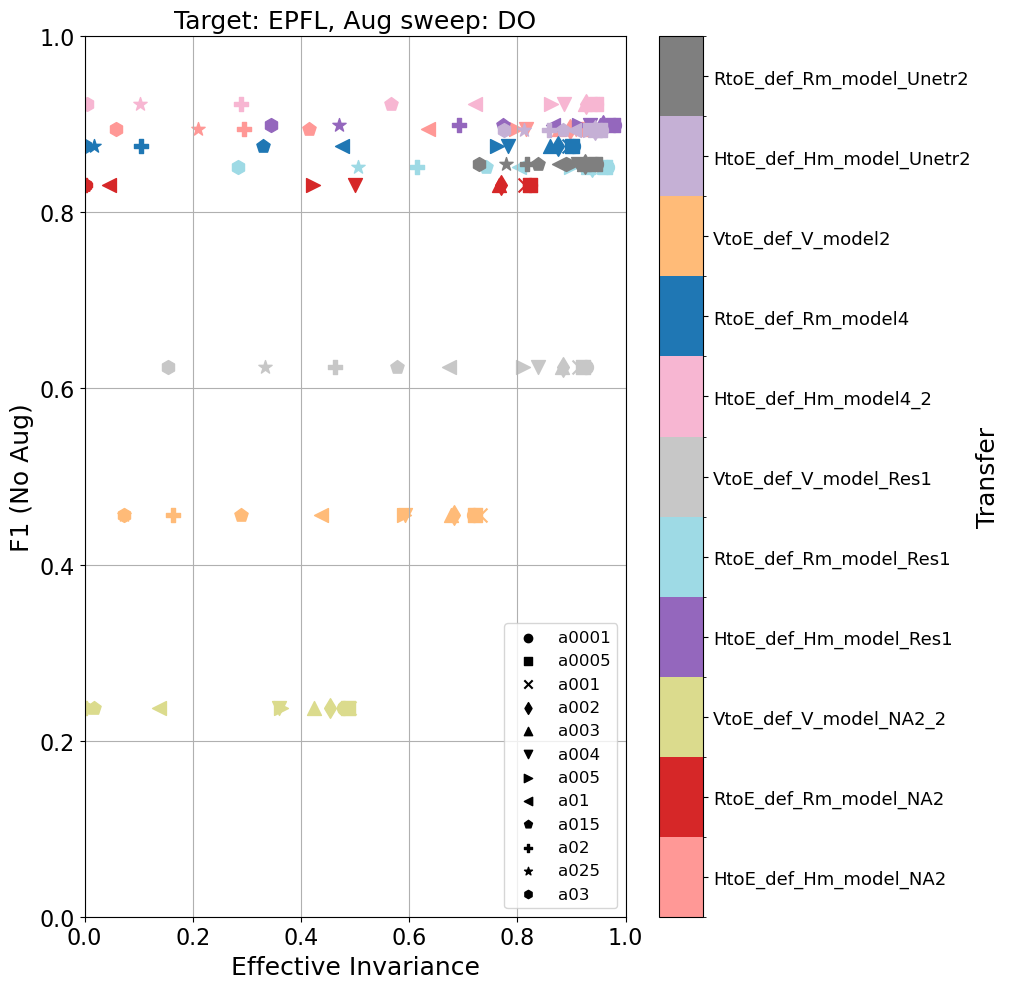

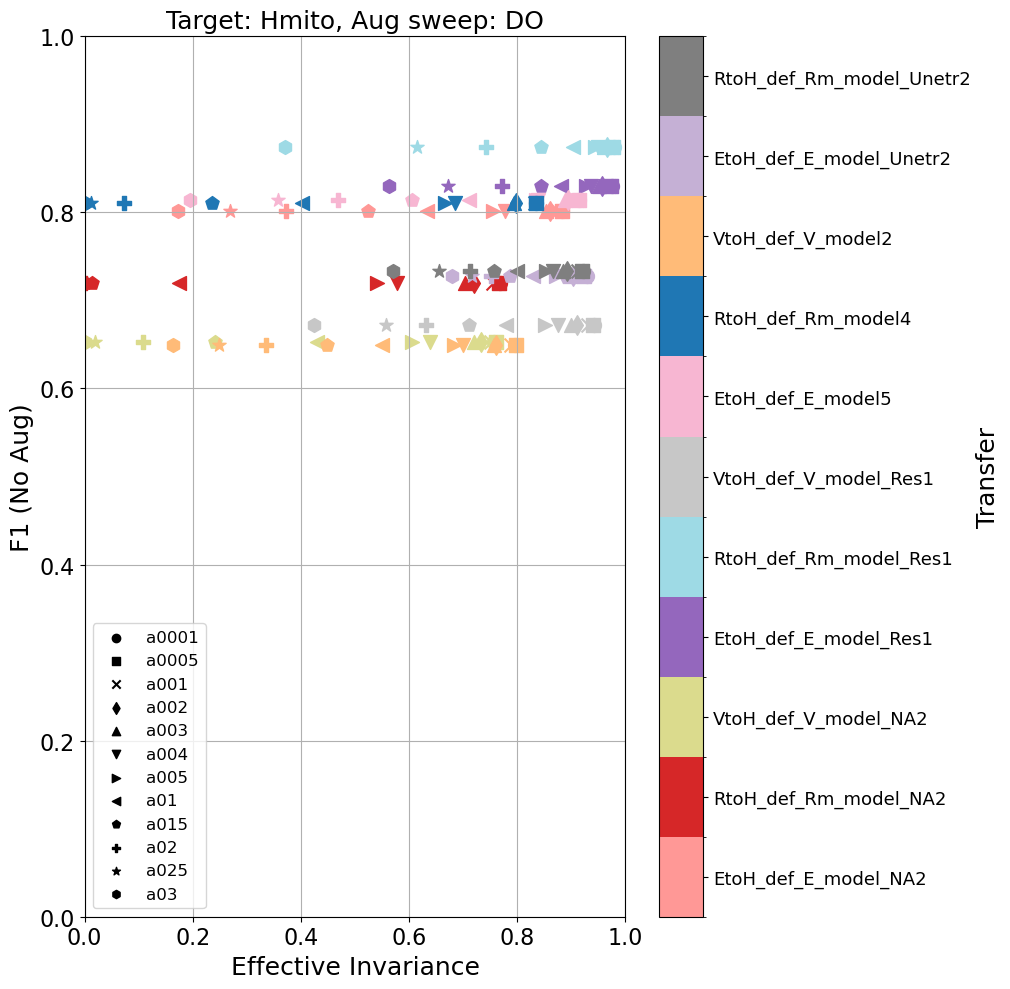

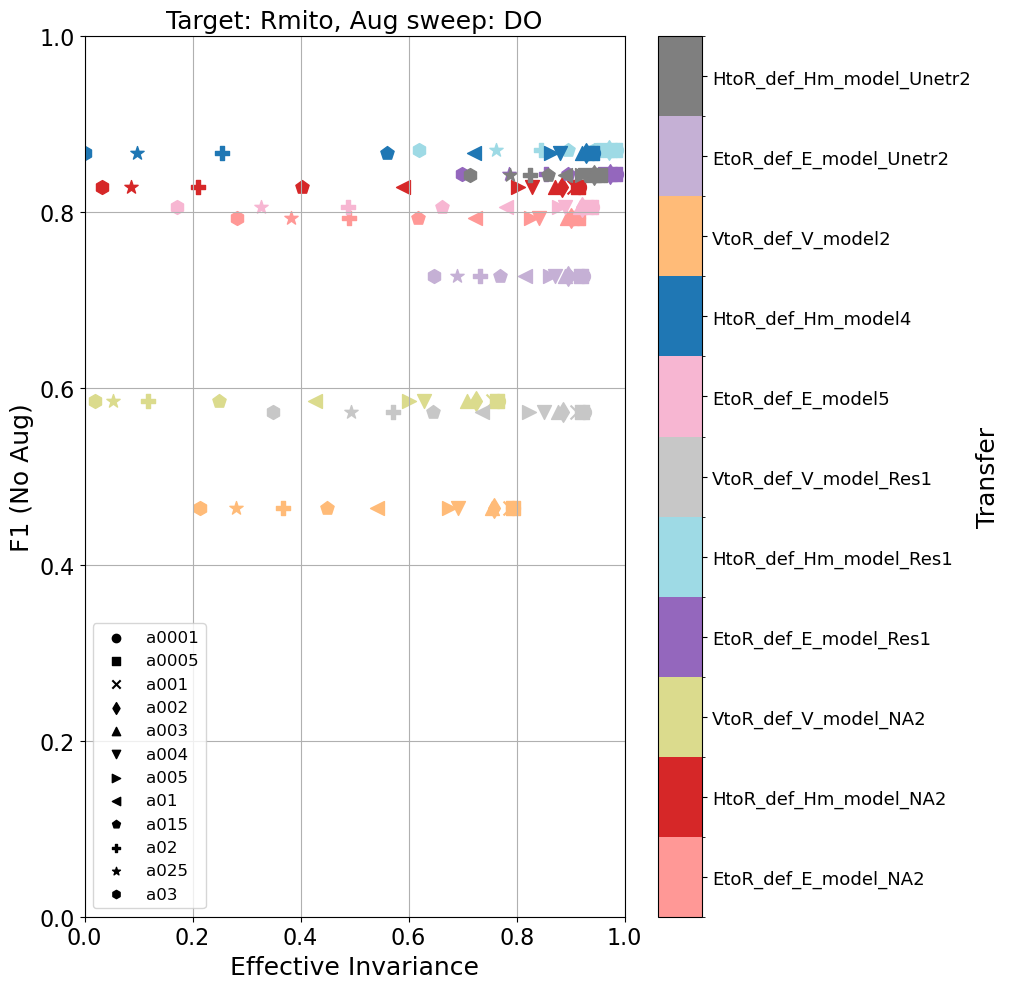

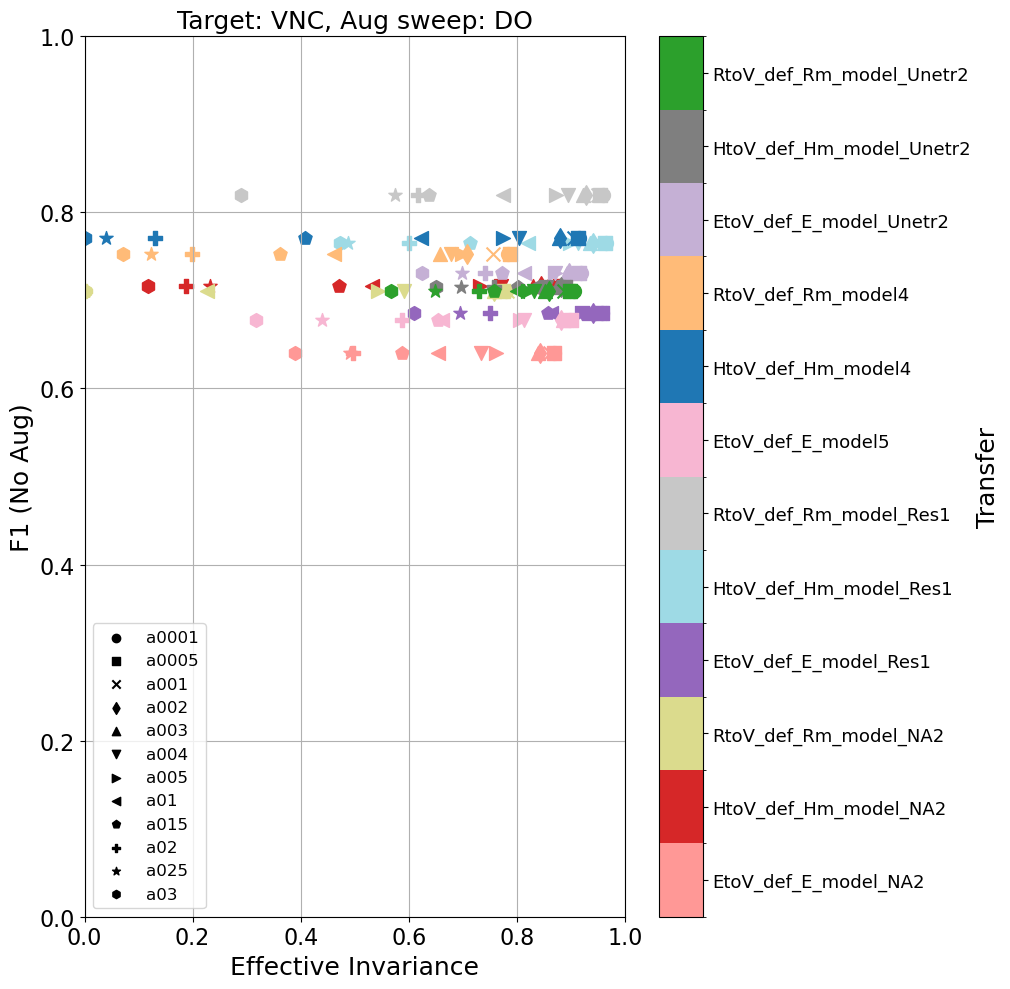

In [9]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["DO"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

In [10]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_forg_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["DO"]),
    perturbation_key="DO"
)
for i in range(len(selected_augmentations['DO'])):
    print(f"DO: {selected_augmentations['DO'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

DO: a0001
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.56     0.02   0.73        0.01  0.91     0.00
     Hmito    0.42     0.13   0.62        0.08  0.59     0.06
     Rmito    0.60     0.01   0.79        0.01  0.81     0.00
     VNC      0.27     0.25   0.41        0.18  0.25     0.42
DO: a0005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.56     0.01   0.73        0.01  0.91     0.00
     Hmito    0.42     0.09   0.62        0.04  0.59     0.06
     Rmito    0.60     0.01   0.79        0.00  0.82     0.00
     VNC      0.21     0.40   0.34        0.30  0.24     0.45
DO: a001
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.56     0.02   0.73        0.01  0.91     0.00
     Hmito    0.42     0.12   0.62       

In [11]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/feature_perturbation_consistency/self_supervised/EI_consistency/FORG"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for i, alpha in enumerate(selected_augmentations['DO']):
    per_target_consistency: Dict[str, Dict[str,float]] = {}
    for target, per_model_consistency in per_target_forg_consistency.items():
        per_target_consistency[target] = {}
        for model, consistency in per_model_consistency.items():
            per_target_consistency[target][model] = consistency['norm_Normalize']['DO'][i]

    # with open(os.path.join(save_path, f"transfer_DO_{alpha}_FORG_05f_05b_EI_scores.json"), "w") as f:
    #     results: Dict[str, Any] = {
    #         "transfer_scores": convert_numpy_types(per_target_consistency),
    #     }
    #     json.dump(results, f, indent=4)

# Background Consistency

In [12]:
per_target_bckg_consistency: Dict[str, Dict[str, Dict[str, Dict[str, NDArray[Any]]]]] = {}
per_target_bckg_performance: Dict[str, Dict[str, Dict[str, NDArray[Any]]]] = {}

for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
        #sources = ["Hmito", "Rmito"]
    elif target == "Hmito":
        sources = ["EPFL", "Rmito", "VNC"]
    elif target == "Rmito":
        sources = ["EPFL", "Hmito", "VNC"]
    else:
        sources = ["Hmito", "Rmito", "VNC"]
    per_source_bckg_consistency = {}
    per_source_bckg_performance = {}

    source_model_types = target_models[target]

    for model_type in source_model_types:
        if target == "EPFL":
            if "Unetr" in model_type["Hmito"]:
                sources = ["Hmito", "Rmito"]
        elif target == "VNC":
            if "Unetr" in model_type["Hmito"]:
                sources = ["EPFL", "Hmito", "Rmito"]
                #sources = ["Hmito", "Rmito"]
        elif target == "Hmito":
            if "Unetr" in model_type["EPFL"]:
                sources = ["EPFL", "Rmito"]
        elif target == "Rmito":
            if "Unetr" in model_type["EPFL"]:
                sources = ["EPFL", "Hmito"]

        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys_bckg,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_bckg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_bckg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
        
    
    per_target_bckg_consistency[target] = per_source_bckg_consistency
    per_target_bckg_performance[target] = per_source_bckg_performance

    

Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 17.89it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 17.54it/s]


Source: VNC


...

100%|██████████| 1/1 [00:00<00:00, 18.58it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 17.91it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 17.68it/s]


In [14]:
per_target_cmb_consistency = cmb_consistency_score_weighted_average(
    per_target_forg_consistency,
    per_target_bckg_consistency,
    w_fg=0.5,
    w_bg=0.5,
    perturbation_key="DO",
)

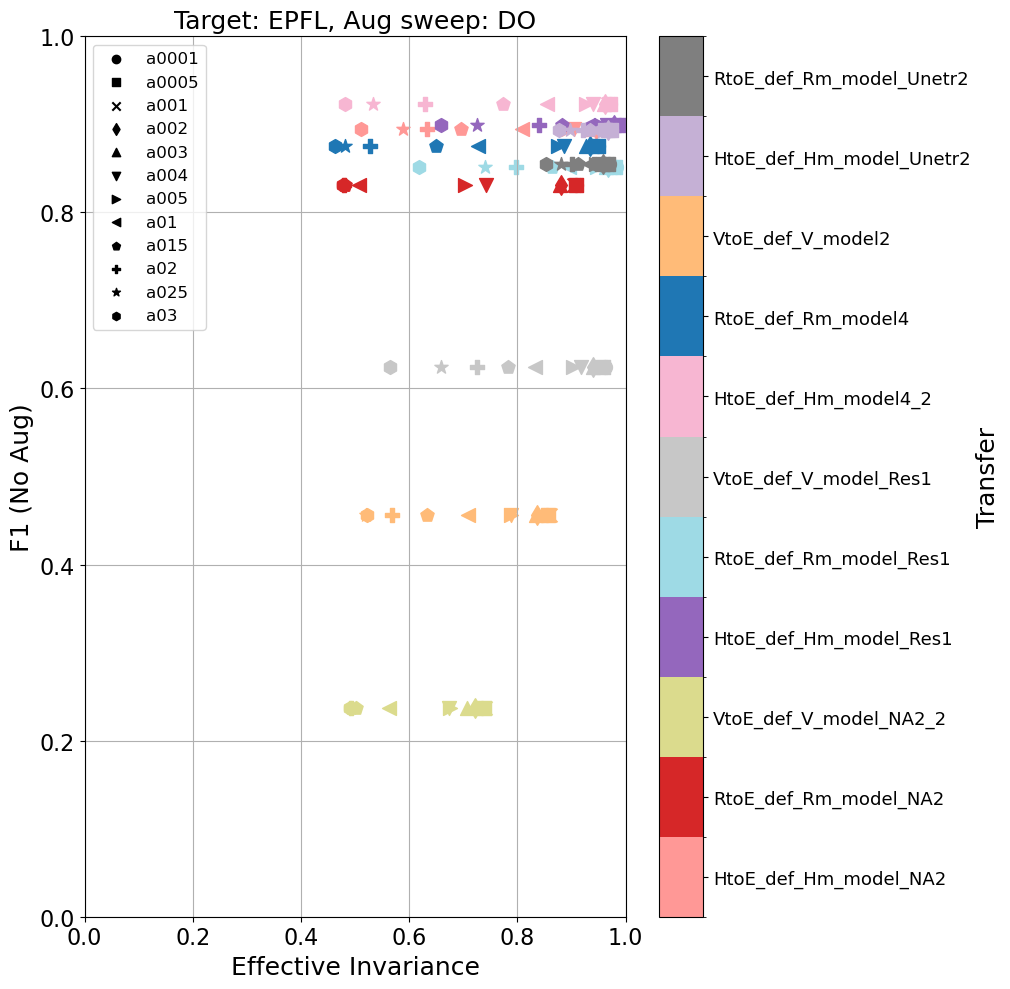

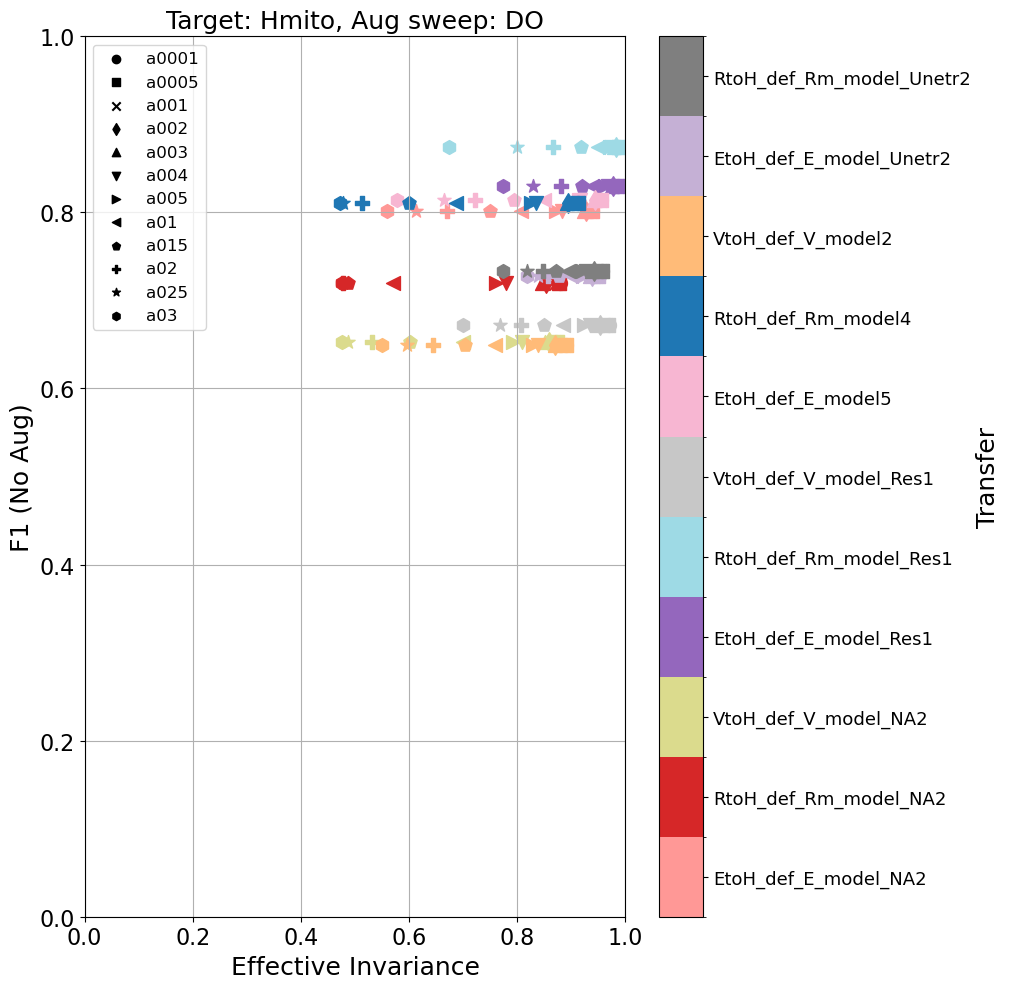

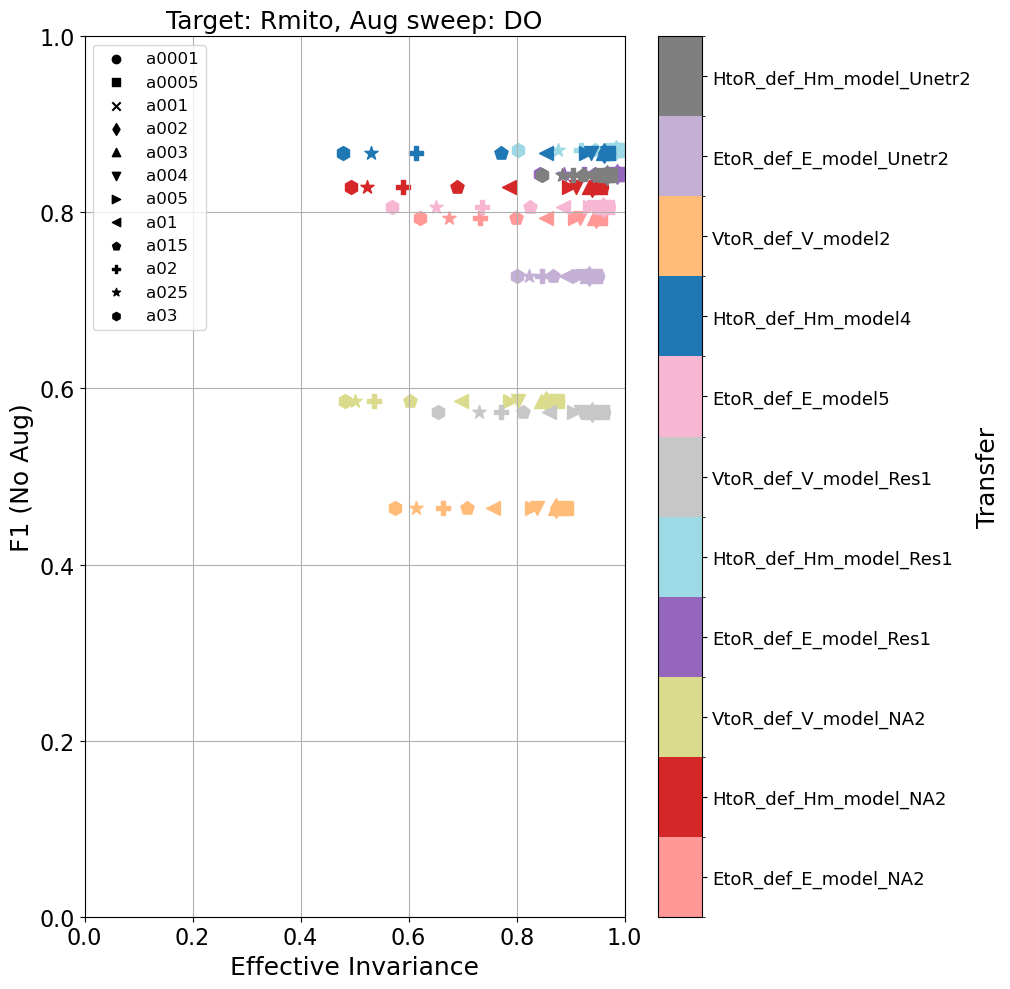

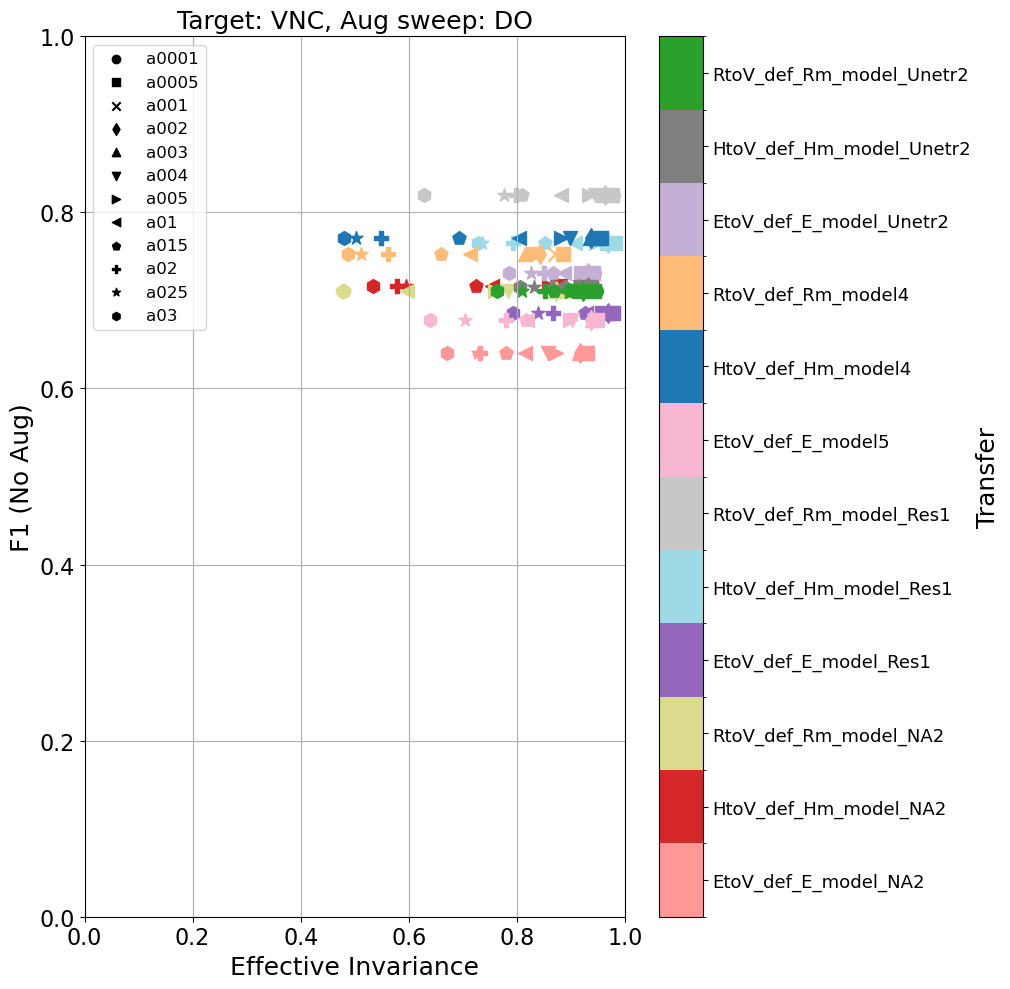

In [15]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        augs=["DO"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

In [17]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_cmb_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["DO"]),
    perturbation_key="DO"
)
for i in range(len(selected_augmentations['DO'])):
    print(f"DO: {selected_augmentations['DO'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

DO: a0001
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.56     0.01   0.73        0.02  0.91     0.00
     Hmito    0.49     0.04   0.66        0.02  0.61     0.05
     Rmito    0.67     0.00   0.83        0.00  0.81     0.00
     VNC      0.27     0.22   0.37        0.21  0.26     0.42
DO: a0005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.56     0.01   0.73        0.01  0.91     0.00
     Hmito    0.49     0.04   0.66        0.03  0.62     0.04
     Rmito    0.67     0.01   0.83        0.00  0.82     0.00
     VNC      0.21     0.34   0.29        0.38  0.24     0.45
DO: a001
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.56     0.02   0.73        0.02  0.91     0.00
     Hmito    0.53     0.02   0.69       

# Save Results

In [16]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_Normalize']
        else:
            per_target_performance[target][model] = performance


In [18]:
per_target_cmb_consistency

{'EPFL': {'HtoE_def_Hm_model_NA2': {'norm_Normalize': {'DO': array([0.9642849 , 0.96372563, 0.95736229, 0.94605994, 0.93511403,
           0.90392494, 0.89349747, 0.80946618, 0.6954077 , 0.63375379,
           0.58881378, 0.51133846])}},
  'RtoE_def_Rm_model_NA2': {'norm_Normalize': {'DO': array([0.90813786, 0.90778467, 0.9037579 , 0.88037509, 0.87870413,
           0.74286616, 0.70299131, 0.50756419, 0.48170137, 0.48043138,
           0.47983408, 0.47837555])}},
  'VtoE_def_V_model_NA2_2': {'norm_Normalize': {'DO': array([0.73525749, 0.73898822, 0.74013193, 0.72135562, 0.70748909,
           0.67435965, 0.67569205, 0.56207748, 0.50145177, 0.49205983,
           0.49159625, 0.48999929])}},
  'HtoE_def_Hm_model_Res1': {'norm_Normalize': {'DO': array([0.98884827, 0.98728377, 0.98337293, 0.97842067, 0.97534272,
           0.96580246, 0.95459774, 0.92977494, 0.88224846, 0.83940467,
           0.72627202, 0.65975776])}},
  'RtoE_def_Rm_model_Res1': {'norm_Normalize': {'DO': array([0.9820306

In [20]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/feature_perturbation_consistency/self_supervised/EI_consistency/CMB"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for i, alpha in enumerate(selected_augmentations['DO']):
    per_target_consistency: Dict[str, Dict[str,float]] = {}
    for target, per_model_consistency in per_target_forg_consistency.items():
        per_target_consistency[target] = {}
        for model, consistency in per_model_consistency.items():
            per_target_consistency[target][model] = consistency['norm_Normalize']['DO'][i]

    with open(os.path.join(save_path, f"transfer_DO_{alpha}_CMB_05f_05b_EI_scores.json"), "w") as f:
        results: Dict[str, Any] = {
            "transfer_scores": convert_numpy_types(per_target_consistency),
        }
        json.dump(results, f, indent=4)